# Phase 2 (part 10b): the redundancy benchmark, corrected drift-localization test (UNSW-NB15, RF + XGBoost)

**Why 10b.** Notebook 10 returned SHAP-ADDS-VALUE-ON-UNSW, but that was a construction
artifact (annotated on F014): its AUC anchor ("which features separate held-out family H from
benign") is the *same task* as `aux-SHAP = SHAP(f_post)` (a benign-vs-H classifier's
attribution), so the anchor was aligned with SHAP, not neutral; and the leave-one-family-out
construction put the other attacks in the pre-window, so KS (which targets the pre->post input
shift) was scored on the wrong contrast and fell *below chance*. That tested attack-attribution,
not drift-localization. C2 is a drift-localization claim. 10b tests it properly.

**The three fixes.**
1. **Additive drift.** post = baseline + injected H at prevalence P; baseline (benign + the
   other attacks) is held constant. The only thing that changes pre->post is H's appearance, so
   every method sees the same "H against baseline" contrast.
2. **Drift-localizers only.** KS(pre, post); **domain-SHAP** = SHAP of a pre-vs-post *domain
   classifier* (the explanation-based drift localizer, directly comparable to KS); **dual-IDS**
   = |SHAP(f_post_IDS) - SHAP(f_pre_IDS)| (the original disagreement hypothesis); perm-domain;
   random. No single IDS model's attribution is used as a "localizer."
3. **Drift-relevant anchor.** Per-feature **Wasserstein-1** between held-out pre and post
   populations -- the features that genuinely drifted. Wasserstein is a different functional
   from the KS statistic, so KS-vs-anchor is not tautological. domain-oracle-SHAP / -gain are
   reported only to expose modality-circularity, as in 10.

**The honest framing of the anchor.** "Which features drifted" is a distributional question,
so the correct truth for drift-localization is distributional (Wasserstein), which naturally
aligns with distributional methods -- that is the substantive point, not circular cheating.
The fair question is whether explanation-based localization (domain-SHAP) can *match* a cheap
label-free KS test on that truth. The dual-IDS-vs-domain-SHAP comparison is fully model-based
and anchor-robust, and corroborates regardless.

**CICIDS reference.** 07c: KS beat aux-SHAP (0.833 vs 0.766); 07d: permutation unstable;
07e/07f: dual adds nothing.

**Pre-registered gate (D027), on the Wasserstein anchor (margin 0.05):**
- *C2-REPLICATES-CROSS-DATASET* — dual-IDS does not beat domain-SHAP (<= margin) AND KS is not
  worse than domain-SHAP (>= -margin). The benchmark claim generalizes to UNSW under real drift.
- *EXPLANATION-ADDS-VALUE-ON-UNSW* — dual does not beat domain-SHAP, but domain-SHAP beats KS
  by > margin on the distributional truth. A genuine refinement of C2 (this time not an
  artifact): explanation-based localization adds value over the cheap test.
- *DUAL-HELPS-ON-UNSW* — dual-IDS beats domain-SHAP by > margin. Partial revival of the
  original hypothesis; focused follow-up.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, glob
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, wasserstein_distance

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    jaccard, random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase2_10b_drift_localization.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
RF_PARAMS = meta06['rf_hyperparameters']
CIC_REF = {'ks_vs_aux_gt2': '+0.067 (KS 0.833 > aux 0.766)', 'dual_adds': 'nothing (07e/07f)'}

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
METHOD_COLOR = {'ks': '#0072B2', 'domain_shap': '#E69F00', 'dual_ids': '#D55E00',
                'perm_domain': '#CC79A7', 'random': '#000000'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='10b_drift_localization_benchmark'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

Setup complete.


## 2. D027 — the corrected drift-localization benchmark and the pre-registered gate

In [3]:
log_decision(
    decision_id='D027',
    decision=(
        'Re-test C2 under real drift on UNSW with a corrected drift-localization design '
        '(supersedes notebook 10 / D026, whose AUC anchor was aligned with aux-SHAP and whose '
        'leave-one-family-out construction confounded KS). (1) Additive drift: post = baseline '
        '+ family H injected at prevalence P, baseline (benign + other attacks) held constant. '
        '(2) Drift-localizers only: KS(pre,post); domain-SHAP (SHAP of a pre-vs-post domain '
        'classifier); dual-IDS (|SHAP(f_post_IDS)-SHAP(f_pre_IDS)|, the original hypothesis); '
        'perm-domain; random. (3) Anchor: per-feature Wasserstein-1 between held-out pre/post '
        'populations (the true drift); domain-oracle-SHAP/-gain reported only for modality-'
        'circularity. RF + XGBoost; several held-out families; permutation self-stability. '
        'Pre-registered gate on the Wasserstein anchor (margin 0.05): '
        'C2-REPLICATES-CROSS-DATASET iff (dual - domain_shap <= margin) AND '
        '(KS - domain_shap >= -margin). EXPLANATION-ADDS-VALUE-ON-UNSW iff '
        '(dual - domain_shap <= margin) AND (domain_shap - KS > margin). '
        'DUAL-HELPS-ON-UNSW iff (dual - domain_shap > margin).'
    ),
    rationale=(
        'C2 is a drift-localization claim: which features distributionally changed. Notebook 10 '
        'accidentally tested attack-attribution (a benign-vs-H model SHAP vs an H-vs-benign '
        'anchor), where SHAP wins near-tautologically and KS, scored on the wrong contrast, '
        'fell below chance. The additive construction makes every method see the same contrast; '
        'the Wasserstein anchor is the honest drift target and a different functional from KS; '
        'comparing KS to a pre-vs-post domain classifier (not an IDS model) is the fair '
        'explanation-vs-cheap-test comparison. dual-vs-domain-SHAP is anchor-robust corroboration.'
    ),
    alternatives=(
        'Re-use notebook 10 unchanged (rejected: construction artifact, annotated on F014). '
        'IDS-model SHAP as the localizer (rejected: that is attack-attribution, the 10 mistake). '
        'Distributional anchor = population KS (rejected: tautological with KS; Wasserstein is a '
        'distinct functional). Replacement drift post=benign+H (rejected: confounds the contrast '
        'with the removal of the other attacks).'
    ),
)

[DECISION LOGGED] D027


## 3. Configuration

In [4]:
set_global_seed(42)

WINDOW = 4000           # rows per pre/post window
INJECT_P = 0.5          # prevalence of H in the post window (the drift magnitude)
ANCHOR_N = 4000         # per-window rows for the held-out Wasserstein anchor
ORACLE_N = 4000         # per-window rows for the domain-oracle GTs
SHAP_SAMPLE = 800
PERM_EVAL = 1200
PERM_REPEATS = 3
SEEDS = [42, 1, 7]
MODELS = ['rf', 'xgb']
N_HELDOUT = 3
MIN_FAMILY = 3000       # need >= WINDOW*INJECT_P rows to inject H
K_PRIMARY = 10
METHODS = ['ks', 'domain_shap', 'dual_ids', 'perm_domain', 'random']
GTS = ['wasserstein', 'domain_oracle_shap', 'domain_oracle_gain']
MARGIN = 0.05

UNSW_PATH = '/content/drive/MyDrive/phd_thesis/data/processed/unsw_nb15/UNSW_NB15_training-set.parquet'

print(f'Additive drift: post = baseline + H at prevalence {INJECT_P}. Models {MODELS}, seeds {SEEDS}.')
print(f'Methods: {METHODS}')
print(f'Primary anchor: per-feature Wasserstein (held-out). Secondary: domain-oracle SHAP/gain.')
print(f'Gate (Wasserstein, margin {MARGIN}): C2 iff dual-domainSHAP <= {MARGIN} AND '
      f'KS-domainSHAP >= -{MARGIN}.')

Additive drift: post = baseline + H at prevalence 0.5. Models ['rf', 'xgb'], seeds [42, 1, 7].
Methods: ['ks', 'domain_shap', 'dual_ids', 'perm_domain', 'random']
Primary anchor: per-feature Wasserstein (held-out). Secondary: domain-oracle SHAP/gain.
Gate (Wasserstein, margin 0.05): C2 iff dual-domainSHAP <= 0.05 AND KS-domainSHAP >= -0.05.


## 4. Load UNSW-NB15 with labels and attack families (as in notebook 10)

In [5]:
df = pd.read_parquet(UNSW_PATH) if str(UNSW_PATH).endswith('parquet') else pd.read_csv(UNSW_PATH)
print('raw shape:', df.shape)
cols_lower = {c.lower(): c for c in df.columns}
LABEL_COL = next((cols_lower[k] for k in ('label', 'target') if k in cols_lower), None)
FAM_COL = next((cols_lower[k] for k in ('attack_category', 'attack_cat', 'category') if k in cols_lower), None)
assert LABEL_COL is not None and FAM_COL is not None, f'need label + family cols; have {list(df.columns)}'

EXCLUDE = {'id', 'label', 'attack_cat', 'attack_category', 'category', 'target', 'index',
           'unnamed: 0', 'source_file', 'attempted'}
numeric = df.select_dtypes(include=[np.number])
FEATURE_COLS = [c for c in numeric.columns if str(c).strip().lower() not in EXCLUDE]
N_FEATURES = len(FEATURE_COLS)

Xall = df[FEATURE_COLS].to_numpy(dtype=float)
y = df[LABEL_COL].to_numpy().astype(int)
fam = df[FAM_COL].astype(str).str.strip().to_numpy()
finite = np.isfinite(Xall).all(axis=1)
Xall, y, fam = Xall[finite], y[finite], fam[finite]
mu, sd = Xall.mean(0), Xall.std(0); sd[sd == 0] = 1.0
Xz = (Xall - mu) / sd
CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)
benign_mask = (y == 0)

print(f'features: {N_FEATURES} | rows: {len(y)} | benign: {int(benign_mask.sum())} | '
      f'attack: {int((~benign_mask).sum())} | chance precision@{K_PRIMARY} = {CHANCE:.3f}')
fam_counts = pd.Series(fam[~benign_mask]).value_counts()
print('\nattack family counts:'); print(fam_counts.to_string())

raw shape: (82332, 46)
features: 42 | rows: 82332 | benign: 37000 | attack: 45332 | chance precision@10 = 0.238

attack family counts:
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44


## 5. Select held-out families

In [6]:
fam_counts = pd.Series(fam[~benign_mask]).value_counts()
eligible = [f for f in fam_counts.index if fam_counts[f] >= MIN_FAMILY and f.lower() != 'normal']
HELDOUT = eligible[:N_HELDOUT]
assert len(HELDOUT) >= 1, f'no attack family has >= {MIN_FAMILY} rows'
print(f'Held-out families (drift scenarios): {HELDOUT}')
for h in HELDOUT:
    print(f'  {h}: {int(fam_counts[h])} rows')
print(f'\nFor each: baseline = benign + (attacks != H); pre = sample(baseline); '
      f'post = (1-{INJECT_P}) baseline + {INJECT_P} H. Anchor = Wasserstein(pre_holdout, post_holdout).')

Held-out families (drift scenarios): ['Generic', 'Exploits', 'Fuzzers']
  Generic: 18871 rows
  Exploits: 11132 rows
  Fuzzers: 6062 rows

For each: baseline = benign + (attacks != H); pre = sample(baseline); post = (1-0.5) baseline + 0.5 H. Anchor = Wasserstein(pre_holdout, post_holdout).


## 6. Run the benchmark (families x models x seeds)

Per family: the Wasserstein anchor on a held-out additive-drift pair, plus a domain oracle
(large pre-vs-post classifier) for the modality-circularity GTs. Per seed: build the additive
pre/post windows, train the two IDS models (for the dual disagreement) and a pre-vs-post domain
classifier (for domain-SHAP / perm-domain), and score KS, domain-SHAP, dual-IDS, perm-domain,
random against every GT.

In [7]:
def make_model(kind, seed):
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

def norm(v):
    v = np.abs(np.asarray(v, float)); s = v.sum(); return v / s if s > 0 else v

def take(pool, n, rng):
    idx = rng.choice(pool, size=min(n, len(pool)), replace=False)
    return Xz[idx], (~benign_mask[idx]).astype(int)

def additive_post(base_pool, hold_pool, n, rng):
    n_h = int(round(n * INJECT_P)); n_b = n - n_h
    bX, by = take(base_pool, n_b, rng); hX, hy = take(hold_pool, n_h, rng)
    X = np.vstack([bX, hX]); yids = np.concatenate([by, hy])
    order = rng.permutation(len(X)); return X[order], yids[order]

rows, stab = [], []
t0 = time.time()
for H in HELDOUT:
    base_pool = np.where(benign_mask | (fam != H))[0]   # benign + all attacks except H
    hold_pool = np.where((~benign_mask) & (fam == H))[0]

    # --- Wasserstein anchor on a held-out additive-drift pair (model-free) ---
    arng = np.random.default_rng(777)
    preA, _ = take(base_pool, ANCHOR_N, arng)
    postA, _ = additive_post(base_pool, hold_pool, ANCHOR_N, arng)
    wass = np.array([wasserstein_distance(preA[:, j], postA[:, j]) for j in range(N_FEATURES)])

    for model in MODELS:
        # --- domain-oracle GTs: a large pre-vs-post classifier (modality refs only) ---
        oPre, _ = take(base_pool, ORACLE_N, arng)
        oPost, _ = additive_post(base_pool, hold_pool, ORACLE_N, arng)
        oX = np.vstack([oPre, oPost]); oy = np.r_[np.zeros(len(oPre), int), np.ones(len(oPost), int)]
        odom = make_model(model, 42).fit(oX, oy)
        oi = np.random.default_rng(42).choice(len(oX), size=min(SHAP_SAMPLE, len(oX)), replace=False)
        gt_scores = {
            'wasserstein': norm(wass),
            'domain_oracle_shap': norm(shap_importance(odom, oX[oi])),
            'domain_oracle_gain': norm(getattr(odom, 'feature_importances_', np.zeros(N_FEATURES))),
        }
        gt_sets = {g: set(int(i) for i in topk_indices(s, K_PRIMARY)) for g, s in gt_scores.items()}

        per_seed_topk = {m: [] for m in METHODS}
        for seed in SEEDS:
            rng = np.random.default_rng(seed)
            preX, pre_y = take(base_pool, WINDOW, rng)
            postX, post_y = additive_post(base_pool, hold_pool, WINDOW, rng)

            # original hypothesis: dual IDS-model SHAP disagreement on shared points
            f_pre = make_model(model, seed).fit(preX, pre_y)
            f_post = make_model(model, seed).fit(postX, post_y)
            sh = postX[rng.choice(len(postX), size=min(SHAP_SAMPLE, len(postX)), replace=False)]
            dual_ids = np.abs(norm(shap_importance(f_post, sh)) - norm(shap_importance(f_pre, sh)))

            # explanation-based drift localizer: pre-vs-post DOMAIN classifier
            domX = np.vstack([preX, postX])
            domy = np.r_[np.zeros(len(preX), int), np.ones(len(postX), int)]
            dtr, dev = train_test_split(np.arange(len(domy)), train_size=0.7,
                                        stratify=domy, random_state=seed)
            dom = make_model(model, seed).fit(domX[dtr], domy[dtr])
            di = rng.choice(dev, size=min(SHAP_SAMPLE, len(dev)), replace=False)
            domain_shap = norm(shap_importance(dom, domX[di]))
            pe = rng.choice(dev, size=min(PERM_EVAL, len(dev)), replace=False)
            perm_domain = norm(np.clip(permutation_importance(
                dom, domX[pe], domy[pe], n_repeats=PERM_REPEATS, random_state=seed).importances_mean, 0, None))

            scores = {
                'ks': ks_drift_scores(preX, postX),
                'domain_shap': domain_shap,
                'dual_ids': dual_ids,
                'perm_domain': perm_domain,
                'random': rng.random(N_FEATURES),
            }
            for m, sc in scores.items():
                per_seed_topk[m].append(set(int(i) for i in topk_indices(sc, K_PRIMARY)))
                for g in GTS:
                    rho = spearmanr(sc, gt_scores[g]).correlation
                    rows.append({'family': H, 'model': model, 'seed': seed, 'method': m, 'gt': g,
                                 'precision': precision_at_k(sc, gt_sets[g], K_PRIMARY),
                                 'spearman': float(rho) if rho == rho else 0.0})
        for m in METHODS:
            tk = per_seed_topk[m]
            js = [jaccard(tk[i], tk[j]) for i in range(len(tk)) for j in range(i + 1, len(tk))]
            stab.append({'family': H, 'model': model, 'method': m,
                         'self_stability': float(np.mean(js)) if js else float('nan')})
        print(f'  {H} / {model} done  ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows); stab_df = pd.DataFrame(stab)
res.to_csv(TABLES / '10b_drift_localization_raw.csv', index=False)
print(f'\n{len(res)} rows; {len(stab_df)} stability records.')

  Generic / rf done  (109s)
  Generic / xgb done  (121s)
  Exploits / rf done  (254s)
  Exploits / xgb done  (265s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Fuzzers / rf done  (402s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Fuzzers / xgb done  (414s)

270 rows; 30 stability records.


## 7. Aggregate — method x GT matrix, KS-vs-domain-SHAP, dual-vs-domain-SHAP

In [8]:
def cell(method, gt, col='precision'):
    s = res[(res['method'] == method) & (res['gt'] == gt)][col]
    return float(s.mean()), float(s.std())

mat = pd.DataFrame({g: [round(cell(m, g)[0], 3) for m in METHODS] for g in GTS}, index=METHODS)
print('precision@%d  (method x ground-truth):' % K_PRIMARY)
print(mat.to_string())
print(f'\nChance ~ {CHANCE:.3f}.  Primary anchor = Wasserstein (drift truth, model-free).')
mat.to_csv(TABLES / '10b_method_gt_matrix.csv')

ks_w = cell('ks', 'wasserstein'); dom_w = cell('domain_shap', 'wasserstein')
dual_w = cell('dual_ids', 'wasserstein'); perm_w = cell('perm_domain', 'wasserstein')
ks_minus_dom = ks_w[0] - dom_w[0]
dual_minus_dom = dual_w[0] - dom_w[0]
print('\nOn the Wasserstein anchor:')
print(f'  KS           {ks_w[0]:.3f} +/- {ks_w[1]:.3f}')
print(f'  domain-SHAP  {dom_w[0]:.3f} +/- {dom_w[1]:.3f}   (KS - domainSHAP = {ks_minus_dom:+.3f})')
print(f'  dual-IDS     {dual_w[0]:.3f} +/- {dual_w[1]:.3f}   (dual - domainSHAP = {dual_minus_dom:+.3f})')
print(f'  perm-domain  {perm_w[0]:.3f} +/- {perm_w[1]:.3f}')

print('\nSelf-stability (mean top-K Jaccard across seeds), by method:')
for m in METHODS:
    print(f'  {m:<12} {stab_df[stab_df["method"] == m]["self_stability"].mean():.3f}')

precision@10  (method x ground-truth):
             wasserstein  domain_oracle_shap  domain_oracle_gain
ks                 0.411               0.561               0.383
domain_shap        0.367               0.789               0.594
dual_ids           0.372               0.539               0.467
perm_domain        0.322               0.572               0.483
random             0.267               0.150               0.211

Chance ~ 0.238.  Primary anchor = Wasserstein (drift truth, model-free).

On the Wasserstein anchor:
  KS           0.411 +/- 0.102
  domain-SHAP  0.367 +/- 0.091   (KS - domainSHAP = +0.044)
  dual-IDS     0.372 +/- 0.127   (dual - domainSHAP = +0.006)
  perm-domain  0.322 +/- 0.117

Self-stability (mean top-K Jaccard across seeds), by method:
  ks           0.791
  domain_shap  0.619
  dual_ids     0.484
  perm_domain  0.323
  random       0.127


## 8. Figure

  saved: 10b_drift_localization_benchmark.png / .pdf


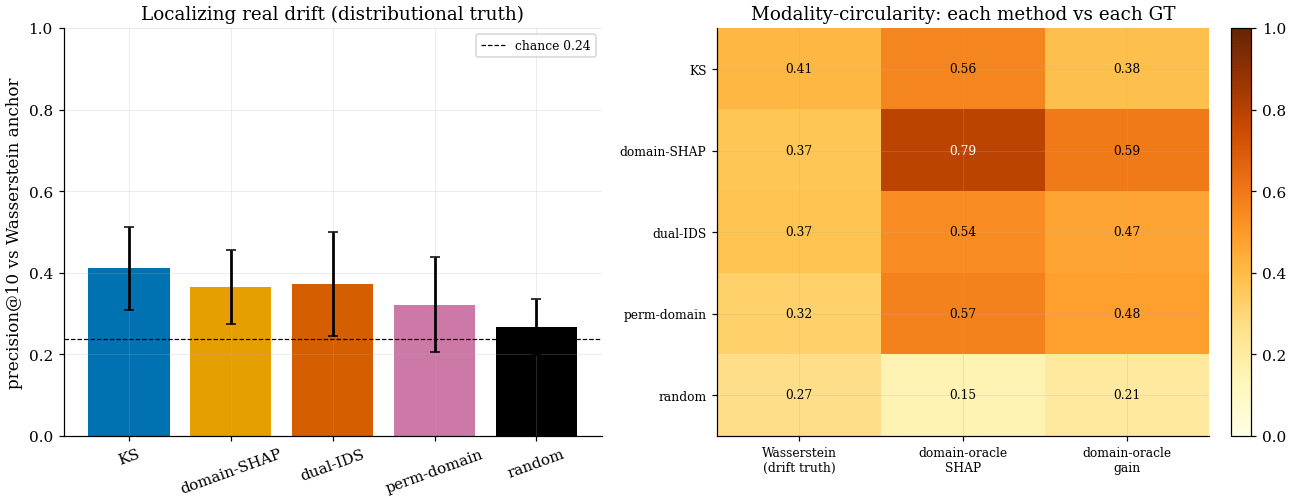

In [9]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.8))

order = ['ks', 'domain_shap', 'dual_ids', 'perm_domain', 'random']
labels = ['KS', 'domain-SHAP', 'dual-IDS', 'perm-domain', 'random']
means = [cell(m, 'wasserstein')[0] for m in order]; errs = [cell(m, 'wasserstein')[1] for m in order]
axA.bar(range(len(order)), means, yerr=errs, capsize=3, color=[METHOD_COLOR[m] for m in order])
axA.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'chance {CHANCE:.2f}')
axA.set_xticks(range(len(order))); axA.set_xticklabels(labels, rotation=20)
axA.set_ylabel(f'precision@{K_PRIMARY} vs Wasserstein anchor')
axA.set_ylim(0, 1.0); axA.set_title('Localizing real drift (distributional truth)')
axA.legend(fontsize=8)

gt_labels = {'wasserstein': 'Wasserstein\n(drift truth)', 'domain_oracle_shap': 'domain-oracle\nSHAP',
             'domain_oracle_gain': 'domain-oracle\ngain'}
M = np.array([[cell(m, g)[0] for g in GTS] for m in METHODS])
im = axB.imshow(M, cmap='YlOrBr', vmin=0, vmax=1, aspect='auto')
axB.set_xticks(range(len(GTS))); axB.set_xticklabels([gt_labels[g] for g in GTS], fontsize=8)
axB.set_yticks(range(len(METHODS))); axB.set_yticklabels(labels, fontsize=8)
for i in range(len(METHODS)):
    for j in range(len(GTS)):
        axB.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=8,
                 color='black' if M[i, j] < 0.6 else 'white')
axB.set_title('Modality-circularity: each method vs each GT')
fig.colorbar(im, ax=axB, fraction=0.046, pad=0.04)
fig.tight_layout(); save_figure(fig, '10b_drift_localization_benchmark'); plt.show()

## 9. Pre-registered verdict (D027)

In [10]:
dual_helps = dual_minus_dom > MARGIN
ks_competitive = ks_minus_dom >= -MARGIN
explanation_adds = (dom_w[0] - ks_w[0]) > MARGIN

if dual_helps:
    verdict = 'DUAL-HELPS-ON-UNSW'
elif ks_competitive:
    verdict = 'C2-REPLICATES-CROSS-DATASET'
elif explanation_adds:
    verdict = 'EXPLANATION-ADDS-VALUE-ON-UNSW'
else:
    verdict = 'MIXED'

dom_inflation = cell('domain_shap', 'domain_oracle_shap')[0] - cell('domain_shap', 'wasserstein')[0]
perm_stab = stab_df[stab_df['method'] == 'perm_domain']['self_stability'].mean()
dom_stab = stab_df[stab_df['method'] == 'domain_shap']['self_stability'].mean()

print('=' * 74)
print('UNSW DRIFT-LOCALIZATION BENCHMARK VERDICT (D027)  -- precision@%d' % K_PRIMARY)
print('=' * 74)
print(f'  families: {HELDOUT} | models: {MODELS} | seeds: {SEEDS} | chance {CHANCE:.3f}')
print(f'  Wasserstein anchor:  KS {ks_w[0]:.3f} | domain-SHAP {dom_w[0]:.3f} | '
      f'dual-IDS {dual_w[0]:.3f} | perm {perm_w[0]:.3f}')
print(f'  KS - domainSHAP = {ks_minus_dom:+.3f} (competitive if >= -{MARGIN})  |  '
      f'dual - domainSHAP = {dual_minus_dom:+.3f} (helps if > {MARGIN})')
print(f'  modality-circularity: domain-SHAP inflates {dom_inflation:+.3f} vs its own oracle GT')
print(f'  self-stability: domain-SHAP {dom_stab:.3f} vs perm-domain {perm_stab:.3f}')
print(f'  CICIDS reference: KS-vs-aux {CIC_REF["ks_vs_aux_gt2"]}; dual adds {CIC_REF["dual_adds"]}')
print('-' * 74)
print(f'--> VERDICT: {verdict}')
MSG = {
    'C2-REPLICATES-CROSS-DATASET': 'Under real distributional drift on UNSW, the original dual '
        'disagreement does not beat a proper domain classifier, and a label-free KS test is at '
        'least as good as explanation-based localization on the distributional truth. C2 '
        'generalizes cross-dataset and cross-model. The notebook-10 SHAP "win" was an artifact.',
    'EXPLANATION-ADDS-VALUE-ON-UNSW': 'dual adds nothing, but domain-SHAP beats KS on the '
        'distributional truth -- a genuine refinement of C2 (not an artifact this time): '
        'explanation-based localization adds value over the cheap test under real UNSW drift.',
    'DUAL-HELPS-ON-UNSW': 'the original dual-IDS disagreement beats a proper domain classifier '
        'on the distributional truth -- a partial revival of the original hypothesis; warrants '
        'a focused follow-up before any positive claim.',
    'MIXED': 'KS, domain-SHAP within margin and dual does not help; report KS ~ domain-SHAP '
        '(consistent with C2, weak form).',
}[verdict]
print('   ' + MSG)

UNSW DRIFT-LOCALIZATION BENCHMARK VERDICT (D027)  -- precision@10
  families: ['Generic', 'Exploits', 'Fuzzers'] | models: ['rf', 'xgb'] | seeds: [42, 1, 7] | chance 0.238
  Wasserstein anchor:  KS 0.411 | domain-SHAP 0.367 | dual-IDS 0.372 | perm 0.322
  KS - domainSHAP = +0.044 (competitive if >= -0.05)  |  dual - domainSHAP = +0.006 (helps if > 0.05)
  modality-circularity: domain-SHAP inflates +0.422 vs its own oracle GT
  self-stability: domain-SHAP 0.619 vs perm-domain 0.323
  CICIDS reference: KS-vs-aux +0.067 (KS 0.833 > aux 0.766); dual adds nothing (07e/07f)
--------------------------------------------------------------------------
--> VERDICT: C2-REPLICATES-CROSS-DATASET
   Under real distributional drift on UNSW, the original dual disagreement does not beat a proper domain classifier, and a label-free KS test is at least as good as explanation-based localization on the distributional truth. C2 generalizes cross-dataset and cross-model. The notebook-10 SHAP "win" was an arti

In [11]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'dataset': 'UNSW-NB15', 'drift': 'additive leave-one-family-out (inject H at P)',
    'inject_p': INJECT_P, 'unsw_file': str(UNSW_PATH), 'n_features': N_FEATURES,
    'heldout_families': HELDOUT, 'models': MODELS, 'seeds': SEEDS, 'k': K_PRIMARY,
    'chance': CHANCE, 'margin': MARGIN,
    'wasserstein_anchor': {'ks': ks_w[0], 'domain_shap': dom_w[0], 'dual_ids': dual_w[0],
                           'perm_domain': perm_w[0],
                           'ks_minus_domainshap': ks_minus_dom, 'dual_minus_domainshap': dual_minus_dom},
    'method_gt_matrix': {m: {g: cell(m, g)[0] for g in GTS} for m in METHODS},
    'domain_shap_inflation_vs_oracle': dom_inflation,
    'self_stability': {m: float(stab_df[stab_df['method'] == m]['self_stability'].mean())
                       for m in METHODS},
    'verdict': verdict, 'supersedes': 'notebook 10 / F014 (construction-limited)',
    'cicids_reference': CIC_REF,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F015',
    title='UNSW corrected drift-localization benchmark: KS vs domain-SHAP vs dual (RF + XGBoost)',
    context='04_phase2_multidataset/10b_drift_localization_benchmark',
    what_we_did=(
        'Corrected the notebook-10 construction artifact (F014). Tested C2 under REAL additive '
        'drift on UNSW (inject family H at prevalence %.2f, baseline held constant), comparing '
        'drift-localizers only -- KS, domain-classifier SHAP, the original dual-IDS '
        'disagreement, perm-domain, random -- against a model-free Wasserstein drift anchor '
        '(domain-oracle GTs for modality-circularity), RF + XGBoost, with a self-stability '
        'check. D027; supersedes D026.' % INJECT_P
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. On the Wasserstein anchor (chance %.3f): KS %.3f, '
        'domain-SHAP %.3f (KS-domainSHAP %+.3f), dual-IDS %.3f (dual-domainSHAP %+.3f), '
        'perm-domain %.3f. domain-SHAP inflates %+.3f against its own oracle GT. Self-stability: '
        'domain-SHAP %.3f vs perm-domain %.3f. Families %s; RF + XGBoost.'
        % (CHANCE, ks_w[0], dom_w[0], ks_minus_dom, dual_w[0], dual_minus_dom, perm_w[0],
           dom_inflation, dom_stab, perm_stab, str(HELDOUT))
    ),
    why_it_matters=(
        'This is the valid cross-dataset test of C2 (KS competitive with explanation-based '
        'localization; original dual disagreement adds nothing) under real drift, replacing the '
        'construction-limited notebook 10. It also re-confirms modality-circularity and '
        'permutation-instability on UNSW -- the core of the C1 evaluation-framework contribution.'
    ),
)
print('F015 logged. Record the call in a hand journal entry.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase2_10b_drift_localization.json
[FINDING LOGGED] F015: UNSW corrected drift-localization benchmark: KS vs domain-SHAP vs dual (RF + XGBoost)
F015 logged. Record the call in a hand journal entry.


## 10. What this settles, and what is next

- **C2-REPLICATES-CROSS-DATASET** closes the breadth phase correctly: with the construction
  fixed, the benchmark claim (KS competitive with explanation-based localization; the original
  dual disagreement adds nothing) holds cross-dataset, cross-model, under real drift -- and the
  notebook-10 SHAP "win" is explained as an attack-attribution artifact, which is itself a clean
  point for the C1 framework (conflating IDS-model attribution with drift-localization is a
  category error).
- **EXPLANATION-ADDS-VALUE-ON-UNSW** would now be a *genuine* refinement rather than an
  artifact: explanation-based localization beating the cheap test on the distributional truth.
  It would sharpen C2's scope (where explanations help vs not) and is fully publishable.
- **DUAL-HELPS-ON-UNSW** would partially revive the original hypothesis and demand follow-up.

After this, the experimental programme is genuinely done. Remaining: consolidation and writing
-- the negative-plus-framework thesis (protocol, redundancy benchmark, synthetic mechanism +
cross-dataset structural block, regime map) -- plus the F001 P(X)-stability check. A third
dataset stays optional.

Record the call by hand:

In [12]:
# add_journal_entry(
#     title='Notebook 10b corrected drift-localization benchmark verdict',
#     body='...the additive-drift construction, KS vs domain-SHAP vs dual-IDS on the Wasserstein '
#          'anchor, the modality-circularity and stability findings, the verdict tier, what it '
#          'settles for C2, and that it supersedes the construction-limited notebook 10.',
# )